In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("obulisainaren/retinal-oct-c8")

print("Path to dataset files:", path)

100%|██████████| 1.42G/1.42G [01:05<00:00, 23.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/obulisainaren/retinal-oct-c8/versions/3


In [3]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.1/57.1 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 95.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.8/930.8 kB 67.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 91.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 97.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 121.0 MB/s eta 0:00:00


In [6]:
import pennylane as qml
from pennylane import numpy as np
from pennylane.templates import RandomLayers
import pandas as pd
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")
print(f"PennyLane version: {qml.__version__}")
print(f"TensorFlow version: {tf.__version__}")

# Step 2: Set dataset paths and parameters
DATASET_PATH = "/root/.cache/kagglehub/datasets/obulisainaren/retinal-oct-c8/versions/3"
IMG_SIZE = (64, 64)  # Image size for processing
BATCH_SIZE = 16
N_QUBITS = 8  # Number of qubits for quantum circuit
N_LAYERS = 3  # Number of quantum layers

print(f"Image size: {IMG_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Number of qubits: {N_QUBITS}")
print(f"Number of quantum layers: {N_LAYERS}")

# Step 3: Data loading function
def load_images_and_labels(dataset_path, img_size):
    """Load images and labels from dataset"""
    data = {'train': {'images': [], 'labels': []},
            'test': {'images': [], 'labels': []},
            'val': {'images': [], 'labels': []}}

    splits = ['train', 'test', 'val']
    classes = ['NORMAL', 'CSR']

    for split in splits:
        for class_idx, class_name in enumerate(classes):
            class_path = os.path.join(dataset_path, 'RetinalOCT_Dataset', 'RetinalOCT_Dataset', split, class_name)

            if os.path.exists(class_path):
                print(f"Loading {split}/{class_name}...")
                count = 0

                for filename in os.listdir(class_path):
                    if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                        try:
                            # Load and preprocess image
                            img_path = os.path.join(class_path, filename)
                            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Grayscale for feature extraction
                            img = cv2.resize(img, img_size)
                            img = img.astype(np.float32) / 255.0  # Normalize

                            data[split]['images'].append(img)
                            data[split]['labels'].append(class_idx)
                            count += 1

                        except Exception as e:
                            print(f"Error loading {filename}: {e}")
                            continue

                print(f"Loaded {count} images for {split}/{class_name}")
            else:
                print(f"Directory not found: {split}/{class_name}")

    # Convert to numpy arrays
    for split in splits:
        if data[split]['images']:
            data[split]['images'] = np.array(data[split]['images'])
            data[split]['labels'] = np.array(data[split]['labels'])
        else:
            data[split]['images'] = np.array([])
            data[split]['labels'] = np.array([])
    return data


Libraries imported successfully!
PennyLane version: 0.42.3
TensorFlow version: 2.19.0
Image size: (64, 64)
Batch size: 16
Number of qubits: 8
Number of quantum layers: 3


In [7]:
print("Loading dataset...")
data = load_images_and_labels(DATASET_PATH, IMG_SIZE)

# Check what data we have
print("\nDataset Summary:")
for split in ['train', 'test', 'val']:
    if len(data[split]['images']) > 0:
        print(f"{split.upper()}: {len(data[split]['images'])} images")
        print(f"  - NORMAL: {np.sum(data[split]['labels'] == 0)}")
        print(f"  - CSR: {np.sum(data[split]['labels'] == 1)}")
    else:
        print(f"{split.upper()}: No data found")

Loading dataset...
Loading train/NORMAL...
Loaded 2300 images for train/NORMAL
Loading train/CSR...
Loaded 2300 images for train/CSR
Loading test/NORMAL...
Loaded 350 images for test/NORMAL
Loading test/CSR...
Loaded 350 images for test/CSR
Loading val/NORMAL...
Loaded 350 images for val/NORMAL
Loading val/CSR...
Loaded 350 images for val/CSR

Dataset Summary:
TRAIN: 4600 images
  - NORMAL: 2300
  - CSR: 2300
TEST: 700 images
  - NORMAL: 350
  - CSR: 350
VAL: 700 images
  - NORMAL: 350
  - CSR: 350


In [8]:
print("\nPreparing data for training...")

if len(data['val']['images']) > 0:
    print("Using separate validation set")
    X_train, y_train = data['train']['images'], data['train']['labels']
    X_val, y_val = data['val']['images'], data['val']['labels']
    X_test, y_test = data['test']['images'], data['test']['labels']
else:
    print("No separate validation set found. Creating validation split from training data...")
    all_images = np.concatenate([data['train']['images'], data['test']['images']])
    all_labels = np.concatenate([data['train']['labels'], data['test']['labels']])

    X_train_temp, X_test, y_train_temp, y_test = train_test_split(
        all_images, all_labels, test_size=0.2, random_state=42, stratify=all_labels
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_temp, y_train_temp, test_size=0.25, random_state=42, stratify=y_train_temp
    )

print(f"Training set: {len(X_train)} images")
print(f"Validation set: {len(X_val)} images")
print(f"Test set: {len(X_test)} images")



Preparing data for training...
Using separate validation set
Training set: 4600 images
Validation set: 700 images
Test set: 700 images


In [9]:
def extract_features_from_images(images, n_features=64):
    """Extract features from images using various statistical measures"""
    features = []

    for img in images:
        # Flatten and get statistical features
        flat_img = img.flatten()

        # Statistical features
        mean_val = np.mean(flat_img)
        std_val = np.std(flat_img)
        min_val = np.min(flat_img)
        max_val = np.max(flat_img)
        median_val = np.median(flat_img)

        # Histogram features
        hist, _ = np.histogram(flat_img, bins=10)
        hist = hist / np.sum(hist)  # Normalize

        # Gradient features
        grad_x = np.gradient(img, axis=0)
        grad_y = np.gradient(img, axis=1)
        grad_magnitude = np.sqrt(grad_x**2 + grad_y**2)
        grad_mean = np.mean(grad_magnitude)
        grad_std = np.std(grad_magnitude)

        # Local Binary Pattern-like features
        center_pixels = img[1:-1, 1:-1]
        neighbor_pixels = [
            img[:-2, :-2], img[:-2, 1:-1], img[:-2, 2:],
            img[1:-1, :-2],               img[1:-1, 2:],
            img[2:, :-2], img[2:, 1:-1], img[2:, 2:]
        ]

        lbp_features = []
        for neighbor in neighbor_pixels:
            lbp_features.append(np.mean(neighbor > center_pixels))

        # Combine all features
        feature_vector = [mean_val, std_val, min_val, max_val, median_val, grad_mean, grad_std] + \
                        list(hist) + lbp_features

        # Add texture features (variance in local windows)
        h, w = img.shape
        for i in range(0, h-8, 8):
            for j in range(0, w-8, 8):
                window = img[i:i+8, j:j+8]
                feature_vector.append(np.var(window))

        features.append(feature_vector[:n_features])  # Limit to n_features

    return np.array(features)

In [10]:
print("Extracting features from images...")
X_train_features = extract_features_from_images(X_train, N_QUBITS)
X_val_features = extract_features_from_images(X_val, N_QUBITS)
X_test_features = extract_features_from_images(X_test, N_QUBITS)


Extracting features from images...


In [11]:
y_train_processed = y_train.astype(int)
y_val_processed = y_val.astype(int)
y_test_processed = y_test.astype(int)


rf = RandomForestClassifier(random_state=42)
rfe = RFE(estimator=rf, n_features_to_select=N_QUBITS)
rfe.fit(X_train_features, y_train_processed)
selected_features = rfe.support_

X_train_selected = X_train_features[:, selected_features]
X_val_selected = X_val_features[:, selected_features]
X_test_selected = X_test_features[:, selected_features]

print(f"Selected Features: {np.where(selected_features)[0]}")


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_selected)
X_val_scaled = scaler.transform(X_val_selected)
X_test_scaled = scaler.transform(X_test_selected)

Selected Features: [0 1 2 3 4 5 6 7]


In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_selected)
X_val_scaled = scaler.transform(X_val_selected)
X_test_scaled = scaler.transform(X_test_selected)

print("Feature preprocessing completed!")


print("Setting up quantum device and circuit...")

n_qubits = X_train_scaled.shape[1]
dev = qml.device("default.qubit", wires=n_qubits)

print(f"Quantum device created with {n_qubits} qubits")


@qml.qnode(dev)
def quantum_node(weights, x):
    """Quantum node for processing features"""

    qml.templates.AngleEmbedding(x, wires=range(n_qubits), rotation="Y")


    qml.templates.BasicEntanglerLayers(weights, wires=range(n_qubits))


    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]


n_layers = N_LAYERS
weight_shape = (n_layers, n_qubits)
rand_params = np.random.uniform(0, 2 * np.pi, weight_shape)

print(f"Quantum circuit initialized with {n_layers} layers")


def quanv(features, weights):
    """Apply the quantum circuit to the features."""
    processed_features = []
    for i, row in enumerate(features):
        if i % 100 == 0:
            print(f"Processing quantum features: {i}/{len(features)}")
        result = quantum_node(weights, row)
        processed_features.append(result)
    return np.array(processed_features)


print("Applying quanvolution to training data...")
q_train = quanv(X_train_scaled, rand_params)

print("Applying quanvolution to validation data...")
q_val = quanv(X_val_scaled, rand_params)

print("Applying quanvolution to test data...")
q_test = quanv(X_test_scaled, rand_params)

print(f"Quantum processed training data shape: {q_train.shape}")

# Step 14: Define Classical Neural Network Model
def create_model(input_shape):
    """Create classical neural network for quantum-processed features"""
    model = keras.models.Sequential([
        keras.layers.Dense(128, activation="relu", input_shape=input_shape),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(32, activation="relu"),
        keras.layers.Dense(2, activation="softmax")  # Binary classification
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# Step 15: Create and train the quantum neural network
print("Creating and training quantum neural network...")

q_model = create_model((q_train.shape[1],))
print(q_model.summary())

# Training callbacks
callbacks = [
    keras.callbacks.EarlyStopping(
        patience=15,
        restore_best_weights=True,
        monitor='val_loss',
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        factor=0.5,
        patience=7,
        monitor='val_loss',
        verbose=1,
        min_lr=1e-6
    ),
    keras.callbacks.ModelCheckpoint(
        'best_quantum_oct_model.h5',
        save_best_only=True,
        monitor='val_accuracy',
        verbose=1
    )
]


Feature preprocessing completed!
Setting up quantum device and circuit...
Quantum device created with 8 qubits
Quantum circuit initialized with 3 layers
Applying quanvolution to training data...
Processing quantum features: 0/4600
Processing quantum features: 100/4600
Processing quantum features: 200/4600
Processing quantum features: 300/4600
Processing quantum features: 400/4600
Processing quantum features: 500/4600
Processing quantum features: 600/4600
Processing quantum features: 700/4600
Processing quantum features: 800/4600
Processing quantum features: 900/4600
Processing quantum features: 1000/4600
Processing quantum features: 1100/4600
Processing quantum features: 1200/4600
Processing quantum features: 1300/4600
Processing quantum features: 1400/4600
Processing quantum features: 1500/4600
Processing quantum features: 1600/4600
Processing quantum features: 1700/4600
Processing quantum features: 1800/4600
Processing quantum features: 1900/4600
Processing quantum features: 2000/460

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,322 (48.13 KB)

 Trainable params: 11,938 (46.63 KB)

 Non-trainable params: 384 (1.50 KB)

None


In [13]:
history = q_model.fit(
    q_train, y_train_processed,
    validation_data=(q_val, y_val_processed),
    epochs=100,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
288/288 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8305 - loss: 0.4019
Epoch 1: val_accuracy improved from -inf to 0.80429, saving model to best_quantum_oct_model.h5


288/288 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.8306 - loss: 0.4016 - val_accuracy: 0.8043 - val_loss: 0.5712 - learning_rate: 0.0010
Epoch 2/100
273/288 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9034 - loss: 0.2505
Epoch 2: val_accuracy improved from 0.80429 to 0.91286, saving model to best_quantum_oct_model.h5


288/288 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9031 - loss: 0.2505 - val_accuracy: 0.9129 - val_loss: 0.2218 - learning_rate: 0.0010
Epoch 3/100
287/288 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9177 - loss: 0.2150
Epoch 3: val_accuracy improved from 0.91286 to 0.93714, saving model to best_quantum_oct_model.h5


288/288 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9177 - loss: 0.2151 - val_accuracy: 0.9371 - val_loss: 0.1515 - learning_rate: 0.0010
Epoch 4/100
278/288 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9120 - loss: 0.2118
Epoch 4: val_accuracy did not improve from 0.93714
288/288 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9120 - loss: 0.2120 - val_accuracy: 0.9300 - val_loss: 0.1435 - learning_rate: 0.0010
Epoch 5/100
279/288 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9210 - loss: 0.1863
Epoch 5: val_accuracy improved from 0.93714 to 0.95143, saving model to best_quantum_oct_model.h5


288/288 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9209 - loss: 0.1867 - val_accuracy: 0.9514 - val_loss: 0.1235 - learning_rate: 0.0010
Epoch 6/100
281/288 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9228 - loss: 0.1951
Epoch 6: val_accuracy improved from 0.95143 to 0.96429, saving model to best_quantum_oct_model.h5


...

288/288 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9399 - loss: 0.1546 - val_accuracy: 0.9757 - val_loss: 0.0714 - learning_rate: 0.0010
Epoch 16/100
273/288 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9416 - loss: 0.1475
Epoch 16: val_accuracy did not improve from 0.97571
288/288 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9415 - loss: 0.1475 - val_accuracy: 0.9629 - val_loss: 0.0990 - learning_rate: 0.0010
Epoch 17/100
269/288 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9431 - loss: 0.1412
Epoch 17: val_accuracy did not improve from 0.97571
288/288 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9432 - loss: 0.1411 - val_accuracy: 0.9757 - val_loss: 0.0781 - learning_rate: 0.0010
Epoch 18/100
274/288 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9490 - loss: 0.1385
Epoch 18: val_accuracy did not improve from 0.97571
288/288 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9489 - loss: 0.1386 - val_accuracy: 0.9714 - val_loss: 0.0777 - learning_rate: 0.0010
Epoch 19/100
267

288/288 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9473 - loss: 0.1367 - val_accuracy: 0.9771 - val_loss: 0.0710 - learning_rate: 0.0010
Epoch 28/100
285/288 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9516 - loss: 0.1190
Epoch 28: val_accuracy did not improve from 0.97714
288/288 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9516 - loss: 0.1192 - val_accuracy: 0.9657 - val_loss: 0.0848 - learning_rate: 0.0010
Epoch 29/100
286/288 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9505 - loss: 0.1257
Epoch 29: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 29: val_accuracy did not improve from 0.97714
288/288 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9505 - loss: 0.1258 - val_accuracy: 0.9671 - val_loss: 0.0811 - learning_rate: 0.0010
Epoch 30/100
282/288 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9584 - loss: 0.1053
Epoch 30: val_accuracy did not improve from 0.97714
288/288 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9583 - loss: 0.1055 - va

288/288 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9603 - loss: 0.1036 - val_accuracy: 0.9800 - val_loss: 0.0613 - learning_rate: 5.0000e-04
Epoch 41/100
270/288 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9587 - loss: 0.1165
Epoch 41: val_accuracy did not improve from 0.98000
288/288 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9586 - loss: 0.1163 - val_accuracy: 0.9757 - val_loss: 0.0599 - learning_rate: 5.0000e-04
Epoch 42/100
269/288 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9595 - loss: 0.0973
Epoch 42: val_accuracy did not improve from 0.98000
288/288 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9595 - loss: 0.0977 - val_accuracy: 0.9757 - val_loss: 0.0687 - learning_rate: 5.0000e-04
Epoch 43/100
267/288 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9625 - loss: 0.1019
Epoch 43: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 43: val_accuracy did not improve from 0.98000
288/288 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9623 - loss:

288/288 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9689 - loss: 0.0867 - val_accuracy: 0.9814 - val_loss: 0.0535 - learning_rate: 1.2500e-04
Epoch 60/100
286/288 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9624 - loss: 0.0937
Epoch 60: val_accuracy did not improve from 0.98143
288/288 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9625 - loss: 0.0937 - val_accuracy: 0.9786 - val_loss: 0.0552 - learning_rate: 1.2500e-04
Epoch 61/100
266/288 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9591 - loss: 0.1001
Epoch 61: val_accuracy did not improve from 0.98143
288/288 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9596 - loss: 0.0991 - val_accuracy: 0.9771 - val_loss: 0.0552 - learning_rate: 1.2500e-04
Epoch 62/100
267/288 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9647 - loss: 0.0907
Epoch 62: val_accuracy did not improve from 0.98143
288/288 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9647 - loss: 0.0909 - val_accuracy: 0.9814 - val_loss: 0.0525 - learning_rate: 1.2500e-04


288/288 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9658 - loss: 0.0878 - val_accuracy: 0.9829 - val_loss: 0.0502 - learning_rate: 1.2500e-04
Epoch 74/100
286/288 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9667 - loss: 0.0997
Epoch 74: val_accuracy did not improve from 0.98286
288/288 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9667 - loss: 0.0996 - val_accuracy: 0.9800 - val_loss: 0.0534 - learning_rate: 1.2500e-04
Epoch 75/100
281/288 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9706 - loss: 0.0888
Epoch 75: val_accuracy did not improve from 0.98286
288/288 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9704 - loss: 0.0890 - val_accuracy: 0.9800 - val_loss: 0.0562 - learning_rate: 1.2500e-04
Epoch 76/100
283/288 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9665 - loss: 0.0891
Epoch 76: val_accuracy did not improve from 0.98286
288/288 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9665 - loss: 0.0892 - val_accuracy: 0.9771 - val_loss: 0.0586 - learning_rate: 1.2500e-04


Evaluating quantum neural network...
Test Accuracy: 0.9800
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step


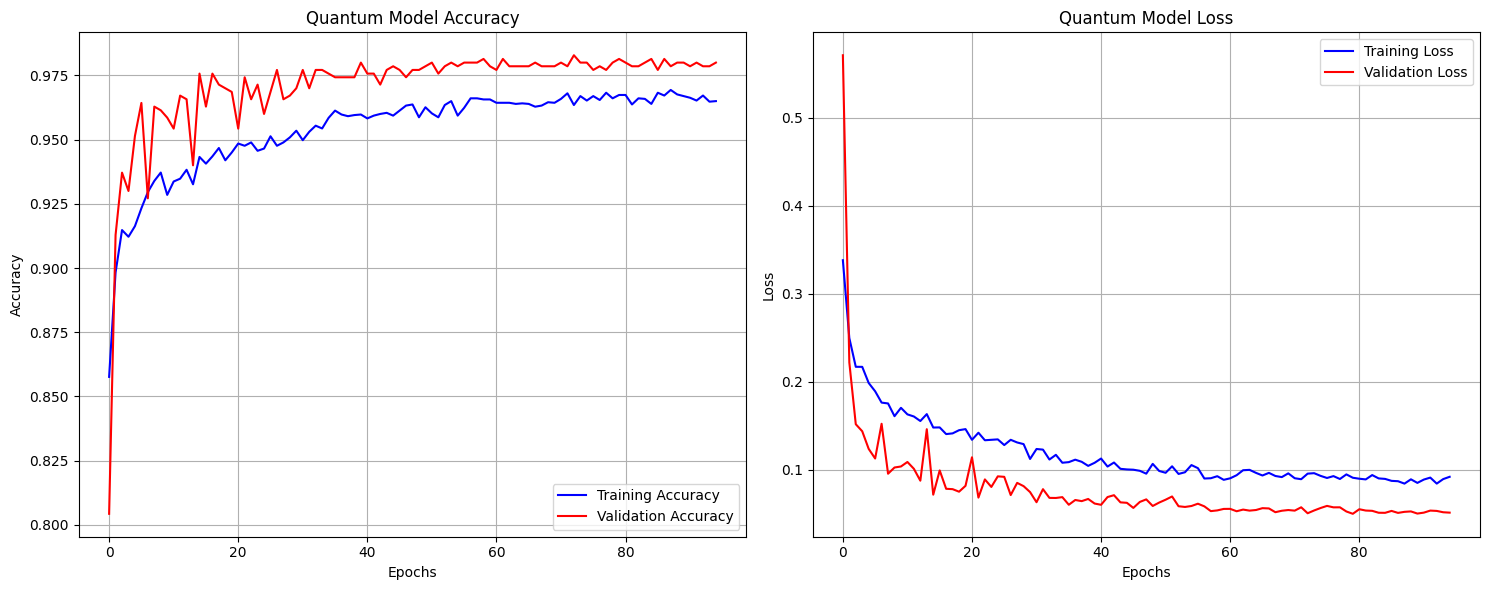

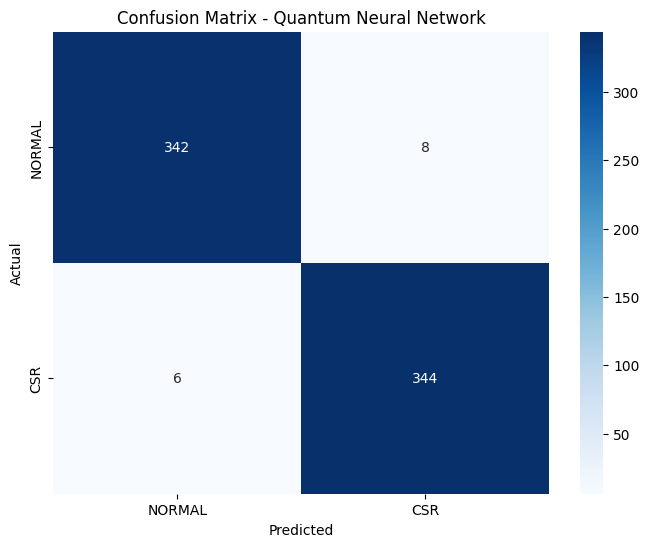


Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.98      0.98      0.98       350
         CSR       0.98      0.98      0.98       350

    accuracy                           0.98       700
   macro avg       0.98      0.98      0.98       700
weighted avg       0.98      0.98      0.98       700



In [14]:
print("Evaluating quantum neural network...")

test_loss, test_accuracy = q_model.evaluate(q_test, y_test_processed, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Make predictions
y_pred = q_model.predict(q_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Step 17: Visualize Results
def plot_training_history(history):
    """Plot training metrics"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    ax1.plot(history.history["accuracy"], label="Training Accuracy", color='blue')
    ax1.plot(history.history["val_accuracy"], label="Validation Accuracy", color='red')
    ax1.set_title("Quantum Model Accuracy")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Accuracy")
    ax1.legend()
    ax1.grid(True)

    ax2.plot(history.history["loss"], label="Training Loss", color='blue')
    ax2.plot(history.history["val_loss"], label="Validation Loss", color='red')
    ax2.set_title("Quantum Model Loss")
    ax2.set_xlabel("Epochs")
    ax2.set_ylabel("Loss")
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

plot_training_history(history)

# Step 18: Confusion Matrix
cm = confusion_matrix(y_test_processed, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL', 'CSR'],
            yticklabels=['NORMAL', 'CSR'])
plt.title('Confusion Matrix - Quantum Neural Network')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Step 19: Classification Report
print("\nClassification Report:")
print(classification_report(y_test_processed, y_pred_classes, target_names=['NORMAL', 'CSR']))

In [15]:
q_model.save('quantum_neural_network_oct.h5')
np.save('quantum_weights.npy', rand_params)
np.save('scaler_params.npy', [scaler.mean_, scaler.scale_])

print("Model and quantum parameters saved!")

Model and quantum parameters saved!
